In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/birds-20-species-image-classification/images to predict/6.jpg
/kaggle/input/birds-20-species-image-classification/images to predict/5.jpg
/kaggle/input/birds-20-species-image-classification/images to predict/1.jpg
/kaggle/input/birds-20-species-image-classification/images to predict/4.jpg
/kaggle/input/birds-20-species-image-classification/images to predict/3.jpg
/kaggle/input/birds-20-species-image-classification/images to predict/2.jpg
/kaggle/input/birds-20-species-image-classification/valid/AMERICAN KESTREL/5.jpg
/kaggle/input/birds-20-species-image-classification/valid/AMERICAN KESTREL/1.jpg
/kaggle/input/birds-20-species-image-classification/valid/AMERICAN KESTREL/4.jpg
/kaggle/input/birds-20-species-image-classification/valid/AMERICAN KESTREL/3.jpg
/kaggle/input/birds-20-species-image-classification/valid/AMERICAN KESTREL/2.jpg
/kaggle/input/birds-20-species-image-classification/valid/AMERICAN GOLDFINCH/5.jpg
/kaggle/input/birds-20-species-image-classification/vali

In [3]:
# SECTION 2: Data Preparation
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset paths
train_dir = "/kaggle/input/birds-20-species-image-classification/train"
val_dir = "/kaggle/input/birds-20-species-image-classification/valid"

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [4]:
# SECTION 3: Save Class Mapping
import json

with open("class_mapping.json", "w") as f:
    json.dump(train_dataset.class_to_idx, f)

print("Saved class mapping:", train_dataset.class_to_idx)

Saved class mapping: {'ABBOTTS BABBLER': 0, 'ABBOTTS BOOBY': 1, 'ABYSSINIAN GROUND HORNBILL': 2, 'AFRICAN CROWNED CRANE': 3, 'AFRICAN EMERALD CUCKOO': 4, 'AFRICAN FIREFINCH': 5, 'AFRICAN OYSTER CATCHER': 6, 'AFRICAN PIED HORNBILL': 7, 'AFRICAN PYGMY GOOSE': 8, 'ALBATROSS': 9, 'ALBERTS TOWHEE': 10, 'ALEXANDRINE PARAKEET': 11, 'ALPINE CHOUGH': 12, 'ALTAMIRA YELLOWTHROAT': 13, 'AMERICAN AVOCET': 14, 'AMERICAN BITTERN': 15, 'AMERICAN COOT': 16, 'AMERICAN FLAMINGO': 17, 'AMERICAN GOLDFINCH': 18, 'AMERICAN KESTREL': 19}


In [5]:
# SECTION 4: Model Definition
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

# Load model with pretrained weights
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(train_dataset.classes))

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


In [6]:
# SECTION 5: Loss and Optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
from tqdm import tqdm
import torch

# Initialize tracking lists
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

num_epochs = 25
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_accuracy = correct / total
    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_accuracy = val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)

    # Save best model
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "best_model.pth")

    # Append metrics for graph
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train loss: {avg_train_loss:.4f}, Train acc: {train_accuracy:.4f} | Val loss: {avg_val_loss:.4f}, Val acc: {val_accuracy:.4f}")

    torch.cuda.empty_cache()

# Save training metrics for later use
torch.save({
    'train_acc': train_accuracies,
    'val_acc': val_accuracies,
    'train_loss': train_losses,
    'val_loss': val_losses
}, 'training_metrics.pth')


Epoch 1/25
Train loss: 0.7258, Train acc: 0.7824 | Val loss: 1.3272, Val acc: 0.7200


Epoch 2/25
Train loss: 0.3764, Train acc: 0.8862 | Val loss: 0.3597, Val acc: 0.8500


Epoch 3/25
Train loss: 0.3527, Train acc: 0.8928 | Val loss: 1.1619, Val acc: 0.7700


Epoch 4/25
Train loss: 0.2789, Train acc: 0.9140 | Val loss: 0.2732, Val acc: 0.8900


Epoch 5/25
Train loss: 0.1992, Train acc: 0.9398 | Val loss: 0.1489, Val acc: 0.9400


...

Epoch 21/25
Train loss: 0.1300, Train acc: 0.9626 | Val loss: 0.0657, Val acc: 0.9700


Epoch 22/25
Train loss: 0.0904, Train acc: 0.9688 | Val loss: 0.1375, Val acc: 0.9500


Epoch 23/25
Train loss: 0.0493, Train acc: 0.9875 | Val loss: 0.1663, Val acc: 0.9600


Epoch 24/25
Train loss: 0.0417, Train acc: 0.9850 | Val loss: 0.0573, Val acc: 0.9700


Epoch 25/25
Train loss: 0.0640, Train acc: 0.9825 | Val loss: 0.1882, Val acc: 0.9500


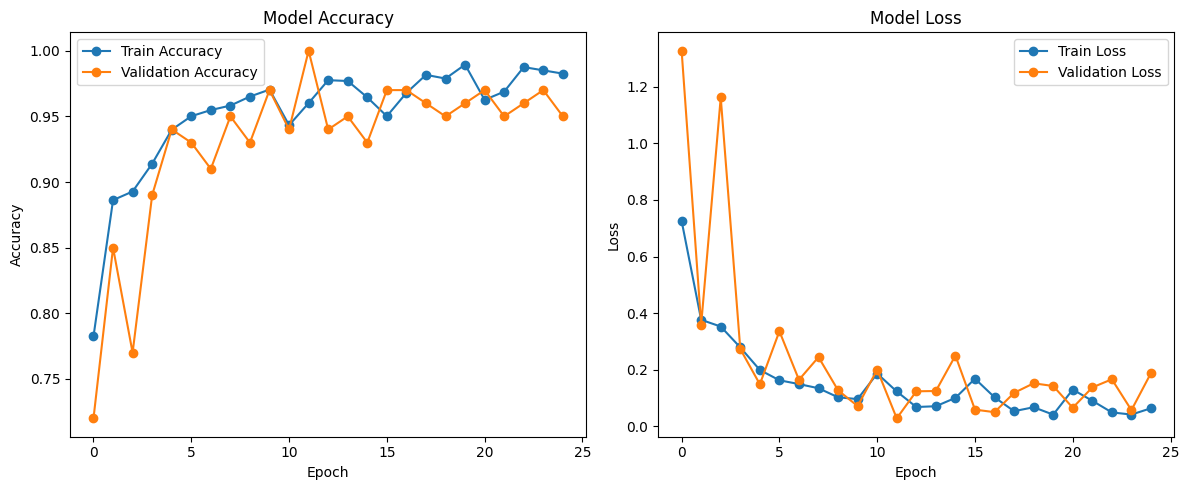

In [8]:
import torch
import matplotlib.pyplot as plt

# Load saved metrics
metrics = torch.load("training_metrics.pth")

# Plotting
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(metrics['train_acc'], label="Train Accuracy", marker='o')
plt.plot(metrics['val_acc'], label="Validation Accuracy", marker='o')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(metrics['train_loss'], label="Train Loss", marker='o')
plt.plot(metrics['val_loss'], label="Validation Loss", marker='o')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

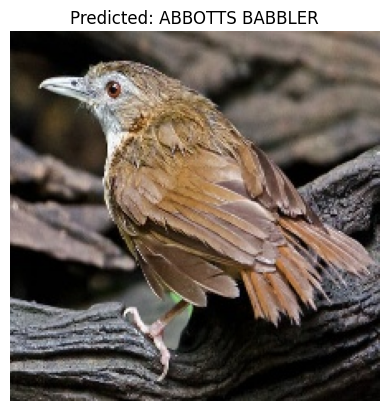

In [9]:
# SECTION 7: Inference
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import json
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the same transform used during validation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load class mapping
if not os.path.exists("class_mapping.json"):
    raise FileNotFoundError("class_mapping.json not found.")

with open("class_mapping.json", "r") as f:
    class_to_idx = json.load(f)

# Reverse mapping: idx -> class name
class_names = [None] * len(class_to_idx)
for class_name, idx in class_to_idx.items():
    class_names[idx] = class_name

# Load model and replace final layer
model = models.resnet18(weights=None)  # Avoid deprecation warning
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

# Load weights
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
model.eval()

# Load and preprocess the test image
img_path = "/kaggle/input/birds-20-species-image-classification/test/ABBOTTS BABBLER/4.jpg"  # Update if needed
image = Image.open(img_path).convert("RGB")
input_tensor = val_transform(image).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    output = model(input_tensor)
    predicted_idx = torch.argmax(output, 1).item()
    predicted_class = class_names[predicted_idx]

# Display result
plt.imshow(image)
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()